#Data Exploration

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import rasterio
import geopandas as gpd 

In [11]:
print("Env ready")
print("Rasterio:", rasterio.__version__)
print("GeoPandas:", gpd.__version__)

Env ready
Rasterio: 1.5.2
GeoPandas: 1.2.0


In [12]:
import geopandas as gpd

aoi = gpd.read_file("../data/aoi/study_area.geojson")

print(aoi)
print()
print("CRS:", aoi.crs)
print("Bounds:", aoi.total_bounds)

   fid                       name  \
0    1  Ahmedabad_Gandhinagar_AOI   

                                            geometry  
0  POLYGON Z ((72.55744 23.18033 0, 72.55755 23.1...  

CRS: EPSG:4326
Bounds: [72.55744464 23.15596316 72.60813514 23.18032797]


In [13]:
aoi = aoi.force_2d()

print("CRS:", aoi.crs)
print("Geometry:", aoi.geometry.iloc[0].geom_type)
print("Bounds:", aoi.total_bounds)

CRS: EPSG:4326
Geometry: Polygon
Bounds: [72.55744464 23.15596316 72.60813514 23.18032797]


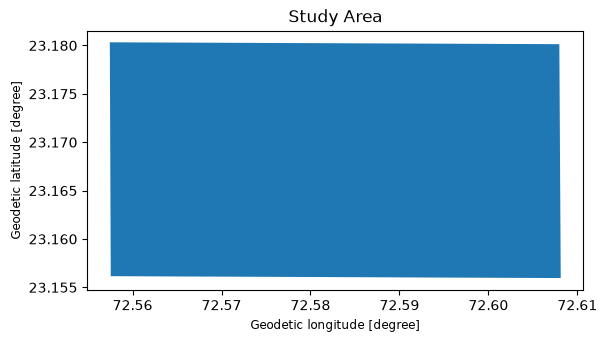

In [14]:
aoi.plot()
plt.title("Study Area")
plt.show()

In [15]:
# Convert AOI to a metric CRS for area calculation
aoi_utm = aoi.to_crs("EPSG:32643")

# Calculate area
area_m2 = aoi_utm.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

print("AOI Area:")
print(f"{area_m2:,.2f} m²")
print(f"{area_km2:.2f} km²")

AOI Area:
13,867,893.25 m²
13.87 km²
